In [16]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Configuración visual para EDA
sns.set_theme(style="whitegrid")
    

In [17]:

# Carga y limpieza de los datasets
df_gen_raw = pd.read_csv('estat_sdg_05_20.tsv', sep='\t')
df_sec_raw = pd.read_csv('estat_earn_gr_gpgr2.tsv', sep='\t')
df_stem_raw = pd.read_csv('estat_educ_uoe_grad04.tsv', sep='\t')


print("--- VISTA PREVIA: BRECHA SALARIAL GENERAL (BRUTO) ---")
print(df_gen_raw.head(3))

print("\n--- INFORMACIÓN ESTRUCTURAL ---")
print(df_gen_raw.info())


--- VISTA PREVIA: BRECHA SALARIAL GENERAL (BRUTO) ---
  freq,unit,nace_r2,geo\TIME_PERIOD 2002   2006   2007   2008   2009   2010   \
0                   A,PC,B-S_X_O,AL    :      :      :      :      :      :    
1                   A,PC,B-S_X_O,AT    :   25.5   25.5   25.1   24.3   24.0    
2                   A,PC,B-S_X_O,BE    :    9.5   10.1   10.2   10.1   10.2    

   2011   2012   2013   ...  2015   2016   2017   2018   2019   2020   2021   \
0     :      :      :   ...     :      :      :    6.8      :      :      :    
1  23.5   22.9   22.3   ...  21.8   20.8   20.7   20.4   20.0   19.2   19.1    
2   9.4    8.3    7.5   ...   6.4    6.0    5.8    5.8    4.7    3.2    1.8    

   2022    2023    2024   
0     :       :       :   
1  18.7   18.3 p  17.6 p  
2   0.7    0.7 p   0.7 p  

[3 rows x 21 columns]

--- INFORMACIÓN ESTRUCTURAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 21 columns):
 #   Column                          

In [18]:

# Función para cargar y limpiar datos de Eurostat
def limpiar_eurostat(df, nombre_valor):
    df.columns = df.columns.str.strip()
    col_dim = df.columns[0]
    dims = col_dim.split('\\')[0].split(',')
    df[dims] = df[col_dim].str.split(',', expand=True)
    df = df.drop(columns=[col_dim])
    
    df_long = pd.melt(df, id_vars=dims, var_name='year', value_name=nombre_valor)
    df_long[nombre_valor] = df_long[nombre_valor].astype(str).str.replace(r'[a-zA-Z\s]', '', regex=True)
    df_long[nombre_valor] = pd.to_numeric(df_long[nombre_valor].replace(':', pd.NA), errors='coerce')
    df_long['year'] = df_long['year'].astype(int)
    
    return df_long


In [32]:

# Limpieza datasets
df_gen = limpiar_eurostat(df_gen_raw, 'brecha_general')
df_sec = limpiar_eurostat(df_sec_raw, 'brecha_sector')
df_stem = limpiar_eurostat(df_stem_raw, 'tasa_stem')

# Verificamos el resultado de la limpieza
print("--- DATOS LIMPIOS Y TRANSFORMADOS ---")
print(df_gen[['geo', 'year', 'brecha_general']].head())
print(f"\nValores nulos detectados en brecha general: {df_gen['brecha_general'].isna().sum()}")


# Filtrado para mujeres en educación terciaria (STEM)
df_stem_f = df_stem[(df_stem['sex'] == 'F') & (df_stem['isced11'] == 'ED5-8')].copy()


# Variables objetivo
df_gen_clean = df_gen[['geo', 'year', 'brecha_general']]
df_stem_clean = df_stem_f[['geo', 'year', 'tasa_stem']]
df_sec_clean = df_sec[['geo', 'year', 'nace_r2', 'brecha_sector']]


# Fusión relacional (Inner Join)
df_master = pd.merge(df_gen_clean, df_stem_clean, on=['geo', 'year'], how='inner')
df_master = pd.merge(df_master, df_sec_clean, on=['geo', 'year'], how='inner')
df_master = df_master.dropna(subset=['brecha_general', 'tasa_stem', 'brecha_sector'])


print(f"Registros totales tras el cruce: {len(df_master)}")
print(df_master.info())


--- DATOS LIMPIOS Y TRANSFORMADOS ---
  geo  year  brecha_general
0  AL  2002             NaN
1  AT  2002             NaN
2  BE  2002             NaN
3  BG  2002            18.9
4  CH  2002             NaN

Valores nulos detectados en brecha general: 171
Registros totales tras el cruce: 6884
<class 'pandas.core.frame.DataFrame'>
Index: 6884 entries, 225 to 9592
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   geo             6884 non-null   object 
 1   year            6884 non-null   int32  
 2   brecha_general  6884 non-null   float64
 3   tasa_stem       6884 non-null   float64
 4   nace_r2         6884 non-null   object 
 5   brecha_sector   6884 non-null   float64
dtypes: float64(3), int32(1), object(2)
memory usage: 349.6+ KB
None


In [20]:

# Carga del dataset recomendado por el profesor (WEF)
df_wef = pd.read_csv('qogdata_03_06_2026.csv', sep=';', decimal=',')
cols_wef = ['cname', 'year', 'gggi_eas', 'gggi_ggi', 'gggi_pos']
df_wef_clean = df_wef[cols_wef].copy()


# Diccionario de mapeo
mapa_paises = {
    'AT': 'Austria', 'BE': 'Belgium', 'BG': 'Bulgaria', 'CH': 'Switzerland',
    'CY': 'Cyprus', 'CZ': 'Czech Republic', 'DE': 'Germany', 'DK': 'Denmark', 
    'EE': 'Estonia', 'EL': 'Greece', 'ES': 'Spain', 'FI': 'Finland', 
    'FR': 'France', 'HR': 'Croatia', 'HU': 'Hungary', 'IE': 'Ireland', 
    'IS': 'Iceland', 'IT': 'Italy', 'LT': 'Lithuania', 'LU': 'Luxembourg', 
    'LV': 'Latvia', 'MK': 'North Macedonia', 'MT': 'Malta', 'NL': 'Netherlands', 
    'NO': 'Norway', 'PL': 'Poland', 'PT': 'Portugal', 'RO': 'Romania', 
    'RS': 'Serbia', 'SE': 'Sweden', 'SI': 'Slovenia', 'SK': 'Slovakia', 
    'UK': 'United Kingdom'
}
df_master['country_name'] = df_master['geo'].map(mapa_paises)


# Fusión definitiva (Left Join) y limpieza final
df_final = pd.merge(df_master, df_wef_clean, 
                    left_on=['country_name', 'year'], 
                    right_on=['cname', 'year'], 
                    how='left')

df_final = df_final.drop(columns=['cname'])


# Guardamos el dataset enriquecido general
df_final.to_csv('dataset_final_infogram.csv', index=False)


In [21]:

# EDA

print("RANGO TEMPORAL DISPONIBLE POR VARIABLE (Valores No Nulos)")


# Calculamos el min y max ignorando los valores nulos (NaN)
bg_min, bg_max = df_final.dropna(subset=['brecha_general'])['year'].min(), df_final.dropna(subset=['brecha_general'])['year'].max()
stem_min, stem_max = df_final.dropna(subset=['tasa_stem'])['year'].min(), df_final.dropna(subset=['tasa_stem'])['year'].max()
sec_min, sec_max = df_final.dropna(subset=['brecha_sector'])['year'].min(), df_final.dropna(subset=['brecha_sector'])['year'].max()
wef_min, wef_max = df_final.dropna(subset=['gggi_ggi'])['year'].min(), df_final.dropna(subset=['gggi_ggi'])['year'].max()

print(f"- Brecha Salarial General: {bg_min} a {bg_max}")
print(f"- Tasa Graduadas STEM: {stem_min} a {stem_max}")
print(f"- Brecha por Sector: {sec_min} a {sec_max}")
print(f"- Índice Global WEF: {wef_min} a {wef_max}\n")


print("RANGO TEMPORAL DISPONIBLE POR PAÍS (Total de la Economía)")

# Filtramos la economía total para no duplicar datos y eliminamos años donde la brecha es nula
df_temporal_paises = df_final[(df_final['nace_r2'] == 'B-S_X_O')].dropna(subset=['brecha_general'])

# Agrupamos por país calculando su primer y último año con datos válidos
rango_paises = df_temporal_paises.groupby('country_name')['year'].agg(['min', 'max']).reset_index()
rango_paises.columns = ['País', 'Primer Año de Datos', 'Último Año de Datos']

# Mostramos la tabla formateada
print(rango_paises.to_string(index=False))


RANGO TEMPORAL DISPONIBLE POR VARIABLE (Valores No Nulos)
- Brecha Salarial General: 2012 a 2024
- Tasa Graduadas STEM: 2012 a 2024
- Brecha por Sector: 2012 a 2024
- Índice Global WEF: 2012 a 2023

RANGO TEMPORAL DISPONIBLE POR PAÍS (Total de la Economía)
           País  Primer Año de Datos  Último Año de Datos
        Austria                 2013                 2024
        Belgium                 2013                 2023
       Bulgaria                 2013                 2024
        Croatia                 2013                 2024
         Cyprus                 2013                 2024
 Czech Republic                 2013                 2023
        Denmark                 2013                 2024
        Estonia                 2013                 2024
        Finland                 2013                 2024
         France                 2015                 2024
        Germany                 2013                 2024
         Greece                 2014           

Dimensiones: (6884, 10)

Estadísticos principales:
        brecha_general    tasa_stem  brecha_sector     gggi_ggi
count     6884.000000  6884.000000    6884.000000  5305.000000
mean        13.050581    12.403835      12.591707     0.755450
std          5.795513     3.985225      10.537832     0.052928
min         -0.900000     1.600000     -54.800000     0.660000
25%          8.700000     9.600000       7.300000     0.720000
50%         13.800000    12.400000      13.000000     0.750000
75%         17.400000    15.000000      18.900000     0.790000
max         29.800000    29.100000      68.400000     0.940000


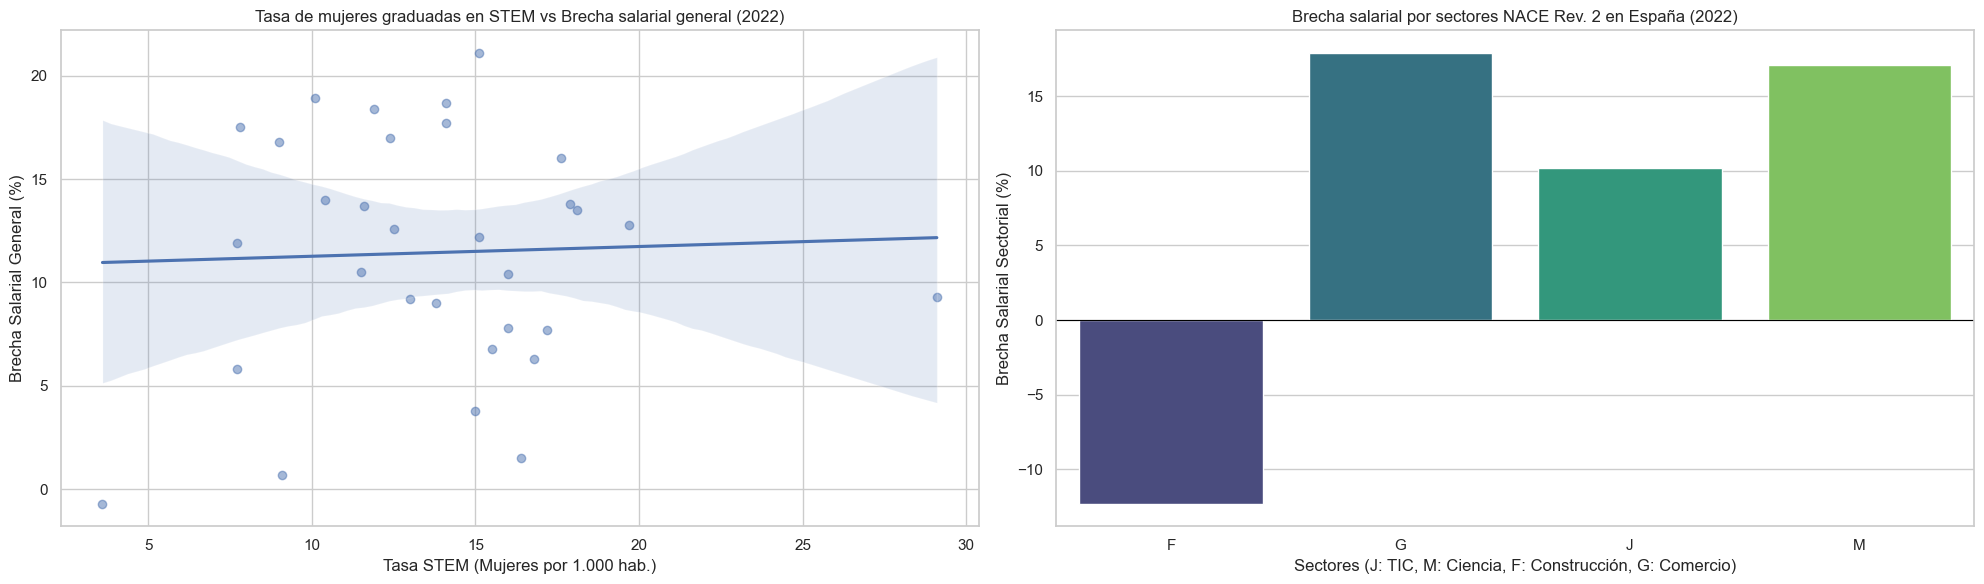

In [22]:

# Estadísticas descriptivas de la matriz consolidada
print("Dimensiones:", df_final.shape)
print("\nEstadísticos principales:\n", df_final[['brecha_general', 'tasa_stem', 'brecha_sector', 'gggi_ggi']].describe())


fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# 1. Relación Tasa STEM vs Brecha General (2022)
df_2022 = df_final[(df_final['year'] == 2022) & (df_final['nace_r2'] == 'B-S_X_O')]
sns.regplot(data=df_2022, x='tasa_stem', y='brecha_general', scatter_kws={'alpha':0.5}, ax=axes[0])
axes[0].set_title('Tasa de mujeres graduadas en STEM vs Brecha salarial general (2022)')
axes[0].set_xlabel('Tasa STEM (Mujeres por 1.000 hab.)')
axes[0].set_ylabel('Brecha Salarial General (%)')


# Comparativa Sectorial en España (2022)
sectores_interes = ['J', 'M', 'F', 'G']
df_comp = df_final[(df_final['geo'] == 'ES') & (df_final['year'] == 2022) & (df_final['nace_r2'].isin(sectores_interes))]
sns.barplot(data=df_comp, x='nace_r2', y='brecha_sector', hue='nace_r2', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Brecha salarial por sectores NACE Rev. 2 en España (2022)')
axes[1].set_xlabel('Sectores (J: TIC, M: Ciencia, F: Construcción, G: Comercio)')
axes[1].set_ylabel('Brecha Salarial Sectorial (%)')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()


In [23]:

# Filtramos la economía total para evitar duplicados en métricas generales
df_base = df_final[df_final['nace_r2'] == 'B-S_X_O'].copy()
df_race = df_base[(df_base['year'] >= 2013) & (df_base['year'] <= 2022)]


# =============================================================================
# 1. MAPA COROPLÉTICO (Año 2022)
# =============================================================================
df_mapa = df_base[df_base['year'] == 2022][['country_name', 'gggi_ggi']].dropna()
df_mapa.to_csv('1_mapa_2022.csv', index=False)


# =============================================================================
# 2. CARRERA DE BARRAS (2013-2022)
# =============================================================================
df_race_pivot = df_race.pivot(index='country_name', columns='year', values='brecha_general').dropna()
df_race_pivot.to_csv('2_evolucion_brecha_13_22.csv')


# =============================================================================
# 3. TABLA COMPARATIVA TOP/FLOP (2013 vs 2022)
# =============================================================================
df_13_22 = df_race_pivot[[2013, 2022]].reset_index()
df_13_22.columns = ['País', 'Brecha_2013', 'Brecha_2022']
df_13_22.to_csv('3_comparativa_extremos_13_22.csv', index=False)


# =============================================================================
# 4. DOBLE EJE (Brecha vs STEM)
# =============================================================================
paises_objetivo = ['Estonia', 'Spain', 'Latvia', 'Italy', 'Belgium']
for pais in paises_objetivo:
    df_pais = df_race[df_race['country_name'] == pais][['year', 'brecha_general', 'tasa_stem']].copy()
    df_pais.columns = ['year', 'Brecha_Total_Economia', 'tasa_stem']
    df_pais.to_csv(f'4_doble_eje_{pais}.csv', index=False)


# =============================================================================
# 5. BARRAS AGRUPADAS (Comparación Sectorial 2022)
# =============================================================================
sectores = ['B-S_X_O', 'J', 'M', 'F']
df_sec = df_final[(df_final['year'] == 2022) & 
                  (df_final['country_name'].isin(paises_objetivo)) & 
                  (df_final['nace_r2'].isin(sectores))]

df_sec_pivot = df_sec.pivot(index='country_name', columns='nace_r2', values='brecha_sector').reset_index()
df_sec_pivot = df_sec_pivot[['country_name', 'B-S_X_O', 'J', 'M', 'F']]
df_sec_pivot.columns = ['País', 'Total Economía', 'Información y Comunicaciones', 'Actividades Científicas', 'Construcción']

df_sec_pivot.to_csv('5_paradoja_sectores_2022.csv', index=False)
